# DS2002 Capstone — EV Charging Station Analytics

**Team Number:** `team-07`

**Team Members:**
- Austin Song (rtx2nb)
- Haero Lee (jva6yw)
- Nate Kim (sax6mw)

**Date:** 2026-03-30

---

## Cloud Setup

Authenticate to GCS, download raw data, and verify your team folder.

In [18]:
# Install the GCS library (run once)
!pip install google-cloud-storage -q

In [19]:
import os
import json
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import numpy as np
from datetime import datetime

from google.colab import auth
auth.authenticate_user()

from google.cloud import storage
client = storage.Client(project="ds2002-492012")
bucket = client.bucket("ds2002-capstone-sp26-v2")
print("GCS authentication successful.")
print(f"Bucket: {bucket.name}")

GCS authentication successful.
Bucket: ds2002-capstone-sp26-v2


In [20]:
# Download raw data from GCS
TEAM = "team-07"  # <-- change to your team number

files = [
    "raw-data/charging_sessions.csv",
    "raw-data/station_locations.csv",
    "raw-data/vehicle_types.csv",
    "raw-data/grid_operators.csv",
    "raw-data/energy_and_demand.db",
]

os.makedirs("data", exist_ok=True)
for f in files:
    blob = bucket.blob(f)
    local = os.path.join("data", os.path.basename(f))
    blob.download_to_filename(local)
    print(f"Downloaded {f}")

Downloaded raw-data/charging_sessions.csv
Downloaded raw-data/station_locations.csv
Downloaded raw-data/vehicle_types.csv
Downloaded raw-data/grid_operators.csv
Downloaded raw-data/energy_and_demand.db


## Data Loading

In [21]:
sessions = pd.read_csv("data/charging_sessions.csv")
stations = pd.read_csv("data/station_locations.csv")
vehicles = pd.read_csv("data/vehicle_types.csv")
operators = pd.read_csv("data/grid_operators.csv")

conn = sqlite3.connect("data/energy_and_demand.db")
demand = pd.read_sql("SELECT * FROM daily_demand_summary", conn)
grid = pd.read_sql("SELECT * FROM grid_capacity_levels", conn)
conn.close()

print(f"Sessions: {sessions.shape}")
print(f"Stations: {stations.shape}")
print(f"Vehicles: {vehicles.shape}")
print(f"Operators: {operators.shape}")
print(f"Demand:   {demand.shape}")
print(f"Grid:     {grid.shape}")

Sessions: (27451, 11)
Stations: (21, 8)
Vehicles: (42, 6)
Operators: (5, 7)
Demand:   (6570, 7)
Grid:     (1825, 6)


## Data Exploration

Inspect each dataset before cleaning.

In [22]:
dfs = {
    'sessions': sessions,
    'stations': stations,
    'vehicles': vehicles,
    'operators': operators,
    'demand': demand,
    'grid': grid
}

# shapes
print("-----df shapes-----")
for name, df in dfs.items():
    print(f"{name}: {df.shape}")

# dtypes
print("\n-----df dtypes-----")
for name, df in dfs.items():
    print(f"\n--{name}:--")
    for col, dtype in df.dtypes.items():
        print(f"  {col}: {dtype}")

# info
print("\n-----df info-----")
for name, df in dfs.items():
    print(f"\n--{name}:--")
    df.info()

# nulls
print("\n-----null counts-----")
for name, df in dfs.items():
    print(f"\n--{name}:--")
    print(df.isnull().sum().to_string())

-----df shapes-----
sessions: (27451, 11)
stations: (21, 8)
vehicles: (42, 6)
operators: (5, 7)
demand: (6570, 7)
grid: (1825, 6)

-----df dtypes-----

--sessions:--
  session_id: object
  station_id: object
  vehicle_id: object
  session_start: object
  session_end: object
  kwh_delivered: float64
  session_type: object
  cost_usd: object
  payment_method: object
  connector_used: object
  user_id: object

--stations:--
  station_id: object
  station_name: object
  city: object
  state: object
  zip_code: int64
  latitude: float64
  longitude: float64
  region: object

--vehicles:--
  vehicle_id: object
  vehicle_name: object
  vehicle_class: object
  connector_type: object
  battery_kwh: object
  manufacturer: object

--operators:--
  operator_id: object
  operator_name: object
  city: object
  state: object
  avg_daily_capacity_mw: int64
  peak_capacity_mw: object
  cost_per_kwh: float64

--demand:--
  date: object
  station_id: object
  total_sessions: int64
  total_kwh_delivered: 

## Data Cleaning Pipeline

Document every cleaning step. Show before and after.

In [23]:
# clean VEHICLES
# standardize strings to fill missing battery_kwh
vehicles['vehicle_name_clean'] = vehicles['vehicle_name'].str.lower().str.strip()
vehicles['vehicle_class_clean'] = vehicles['vehicle_class'].str.lower().str.strip()

# create a reference map for battery capacity
cap_map = vehicles.dropna(subset=['battery_kwh']).set_index(['vehicle_name_clean', 'vehicle_class_clean'])['battery_kwh'].to_dict()

# fill missing values using the map
def fill_kwh(row):
    if pd.isna(row['battery_kwh']) or row['battery_kwh'] == '':
        return cap_map.get((row['vehicle_name_clean'], row['vehicle_class_clean']))
    return row['battery_kwh']

vehicles['battery_kwh'] = vehicles.apply(fill_kwh, axis=1)

# filter to only standard IDs (VH-###) AFTER all previous cleaning steps on 'vehicles'
vehicles = vehicles[vehicles['vehicle_id'].str.contains('^VH-', na=False)].copy()
vehicles.drop(columns=['vehicle_name_clean', 'vehicle_class_clean'], inplace=True)

# fix ccs capitalization
vehicles['connector_type'] = vehicles['connector_type'].str.replace('ccs', 'CCS', case=False)

#fix special characters
vehicles['battery_kwh'] = vehicles['battery_kwh'].str.replace(r'\$', '', regex=True)

# fix NaN manufacturers
vehicles['manufacturer'] = vehicles.apply(
    lambda row: row['vehicle_name'].split()[0] if pd.isna(row['manufacturer']) or row['manufacturer'].strip() == '' else row['manufacturer'],
    axis=1
)

# clean STATIONS
# regulate station state
stations = stations[stations['state'].str.upper().str.strip() == 'VA'].copy()

# regulate station ID
stations['station_id'] = stations['station_id'].str.replace(r'[-_]?(\d+)', lambda m: f"-{m.group(1).zfill(3)}", regex=True)

# get rid of nans and dupes
stations.dropna(inplace=True)
stations.drop_duplicates(subset = ["latitude", "longitude"], inplace=True)

# clean OPERATORS
operators['peak_capacity_mw'] = operators['peak_capacity_mw'].str.replace(r'[^a-zA-Z0-9]', '', regex=True)
operators['cost_per_kwh'] = operators['cost_per_kwh'].fillna(round(operators['cost_per_kwh'].median(), 2))

# drop any null
operators.dropna(inplace=True)

# clean SESSIONS
sessions = sessions.sort_values('station_id').reset_index(drop=True)
vehicle_id_map = {
    # VEH#000X → VH-00X format
    'VEH#0001': 'VH-001',
    'VEH#0002': 'VH-002',
    'VEH#0003': 'VH-003',
    'VEH#0004': 'VH-004',
    'VEH#0005': 'VH-005',
    'VEH#0006': 'VH-006',
    'VEH#0007': 'VH-007',
    'VEH#0008': 'VH-008',
    'VEH#0009': 'VH-009',
    'VEH#0010': 'VH-010',
    'VEH#0011': 'VH-011',
    'VEH#0012': 'VH-012',
    'VEH#0013': 'VH-013',
    'VEH#0014': 'VH-014',
    # V_name style — match to vehicles_cleaned by name
    'V_tesla_model_3':     'VH-001',
    'V_tesla_model_y':     'VH-002',
    'V_tesla_model_s':     'VH-003',
    'V_chevrolet_bolt_ev': 'VH-004',
    'V_chevrolet_bolt_euv':'VH-005',
    'V_ford_f-150_lightning': 'VH-006',
    'V_hyundai_ioniq_5':   'VH-007',
    'V_bmw_ix':            'VH-008',
    'V_lucid_air':         'VH-009',
    'V_rivian_r1t':        'VH-010',
    'V_ford_mustang_mach-e': 'VH-011',
    'V_nissan_leaf':       'VH-012',
    'V_kia_ev6':           'VH-013',
    'V_volkswagen_id.4':   'VH-014',
}

# standardize vehicle ids
sessions['vehicle_id'] = sessions['vehicle_id'].replace(vehicle_id_map)

#standardize stations IDs
sessions['station_id'] = sessions['station_id'].str.replace(r'(?<=[a-zA-Z])(?=\d)|(?<=\d)(?=[a-zA-Z])', '-', regex=True)
sessions['station_id'] = sessions['station_id'].str.replace(r'-(\d{1,2})$', lambda m: f"-{m.group(1).zfill(3)}", regex=True) #used ai here

#standardize session start and end
sessions['session_start'] = pd.to_datetime(sessions['session_start'], format = 'mixed')
sessions['session_end'] = pd.to_datetime(sessions['session_end'], format = 'mixed')

# clean $
sessions['cost_usd'] = sessions['cost_usd'].astype(str).str.replace(r'\$', '', regex=True)
sessions['cost_usd'] = pd.to_numeric(sessions['cost_usd'], errors='coerce')

# clean payment method
sessions['payment_method'] = sessions['payment_method'].str.lower().str.replace(r'\s', '_', regex=True)

# drop null values. Can't replace them with anything, they're pure inputs from users. Dropped 300 columns of 27,451
sessions.dropna(inplace=True)

In [24]:
#upload to cloud
team_prefix = "team-07"

sessions.to_csv("cleaned_sessions.csv", index=False)
stations.to_csv("cleaned_stations.csv", index=False)
vehicles.to_csv("cleaned_vehicles.csv", index=False)
operators.to_csv("cleaned_operators.csv", index=False)
demand.to_csv("demand.csv", index=False)
grid.to_csv("grid.csv", index=False)


files_to_upload = [
    "cleaned_sessions.csv",
    "cleaned_stations.csv",
    "cleaned_vehicles.csv",
    "cleaned_operators.csv",
    "demand.csv",
    "grid.csv"
]

for filename in files_to_upload:
    blob = bucket.blob(f"{team_prefix}/{filename}")
    blob.upload_from_filename(filename)
    print(f"Uploaded {filename} -> gs://ds2002-capstone-sp26-v2/{team_prefix}/{filename}")

Uploaded cleaned_sessions.csv -> gs://ds2002-capstone-sp26-v2/team-07/cleaned_sessions.csv
Uploaded cleaned_stations.csv -> gs://ds2002-capstone-sp26-v2/team-07/cleaned_stations.csv
Uploaded cleaned_vehicles.csv -> gs://ds2002-capstone-sp26-v2/team-07/cleaned_vehicles.csv
Uploaded cleaned_operators.csv -> gs://ds2002-capstone-sp26-v2/team-07/cleaned_operators.csv
Uploaded demand.csv -> gs://ds2002-capstone-sp26-v2/team-07/demand.csv
Uploaded grid.csv -> gs://ds2002-capstone-sp26-v2/team-07/grid.csv


## External API Integration

Pull weather or energy data and join with your charging data.

In [25]:
# Your API code here


---

## Question 1: Demand Surge Identification

> Which time periods experienced the greatest charging demand surges compared to the baseline?

In [26]:
sessions_q1 = sessions.copy()
sessions_q1['date'] = pd.to_datetime(sessions_q1['session_start'].dt.date)

daily = (sessions_q1
         .groupby('date')
         .agg(total_sessions=('session_id', 'count'),
              total_kwh=('kwh_delivered', 'sum'),
              total_revenue=('cost_usd', 'sum'))
         .reset_index()
         .sort_values('date')
         .reset_index(drop=True))

# 30-day centered rolling baseline + std (min_periods=7 keeps edge days in)
window = 30
daily['baseline_sessions'] = daily['total_sessions'].rolling(window, min_periods=7, center=True).mean()
daily['baseline_kwh']      = daily['total_kwh'].rolling(window, min_periods=7, center=True).mean()
daily['std_sessions']      = daily['total_sessions'].rolling(window, min_periods=7, center=True).std()
daily['std_kwh']           = daily['total_kwh'].rolling(window, min_periods=7, center=True).std()

# % lift (what the prompt asks for) and z-score (used for ranking)
daily['pct_lift_sessions'] = (daily['total_sessions'] - daily['baseline_sessions']) / daily['baseline_sessions'] * 100
daily['pct_lift_kwh']      = (daily['total_kwh']      - daily['baseline_kwh'])      / daily['baseline_kwh']      * 100
daily['z_sessions']        = (daily['total_sessions'] - daily['baseline_sessions']) / daily['std_sessions']
daily['z_kwh']             = (daily['total_kwh']      - daily['baseline_kwh'])      / daily['std_kwh']

# Top 10 surge days — % increase in BOTH sessions and kWh side-by-side
print("Top 10 surge days — % increase in daily sessions AND total kWh:")
top_surges = (daily.dropna(subset=['z_sessions'])
                   .nlargest(10, 'z_sessions')
                   [['date',
                     'total_sessions', 'baseline_sessions', 'pct_lift_sessions',
                     'total_kwh', 'baseline_kwh', 'pct_lift_kwh',
                     'z_sessions', 'z_kwh']])
num_cols = top_surges.select_dtypes(include='number').columns
top_surges[num_cols] = top_surges[num_cols].round(2)
print(top_surges.to_string(index=False))

# Top 5 surge months — sustained elevated periods vs. yearly average
daily['month'] = daily['date'].dt.to_period('M')
monthly = (daily.groupby('month')
                .agg(avg_daily_sessions=('total_sessions', 'mean'),
                     avg_daily_kwh=('total_kwh', 'mean'))
                .reset_index())
overall_sessions = daily['total_sessions'].mean()
overall_kwh      = daily['total_kwh'].mean()
monthly['pct_vs_overall_sessions'] = (monthly['avg_daily_sessions'] - overall_sessions) / overall_sessions * 100
monthly['pct_vs_overall_kwh']      = (monthly['avg_daily_kwh']      - overall_kwh)      / overall_kwh      * 100

print("\nTop 5 surge months — % increase vs. overall average:")
top_months = monthly.nlargest(5, 'pct_vs_overall_sessions').copy()
num_cols = top_months.select_dtypes(include='number').columns
top_months[num_cols] = top_months[num_cols].round(2)
print(top_months.to_string(index=False))

Top 10 surge days — % increase in daily sessions AND total kWh:
      date  total_sessions  baseline_sessions  pct_lift_sessions  total_kwh  baseline_kwh  pct_lift_kwh  z_sessions  z_kwh
2025-09-06             152              74.73             103.39    5323.10       2323.31        129.12        3.12   3.81
2025-10-18             156              76.40             104.19    4654.58       2368.66         96.51        2.73   2.64
2025-09-27             160              77.23             107.16    4902.38       2397.92        104.44        2.70   2.93
2025-11-15             165              75.17             119.51    5616.48       2365.36        137.45        2.65   2.92
2025-09-20             155              77.43             100.17    4233.77       2440.13         73.51        2.46   1.89
2025-11-08             152              74.77             103.30    5028.82       2405.19        109.08        2.37   2.42
2025-11-29             135              73.20              84.43    3960.42

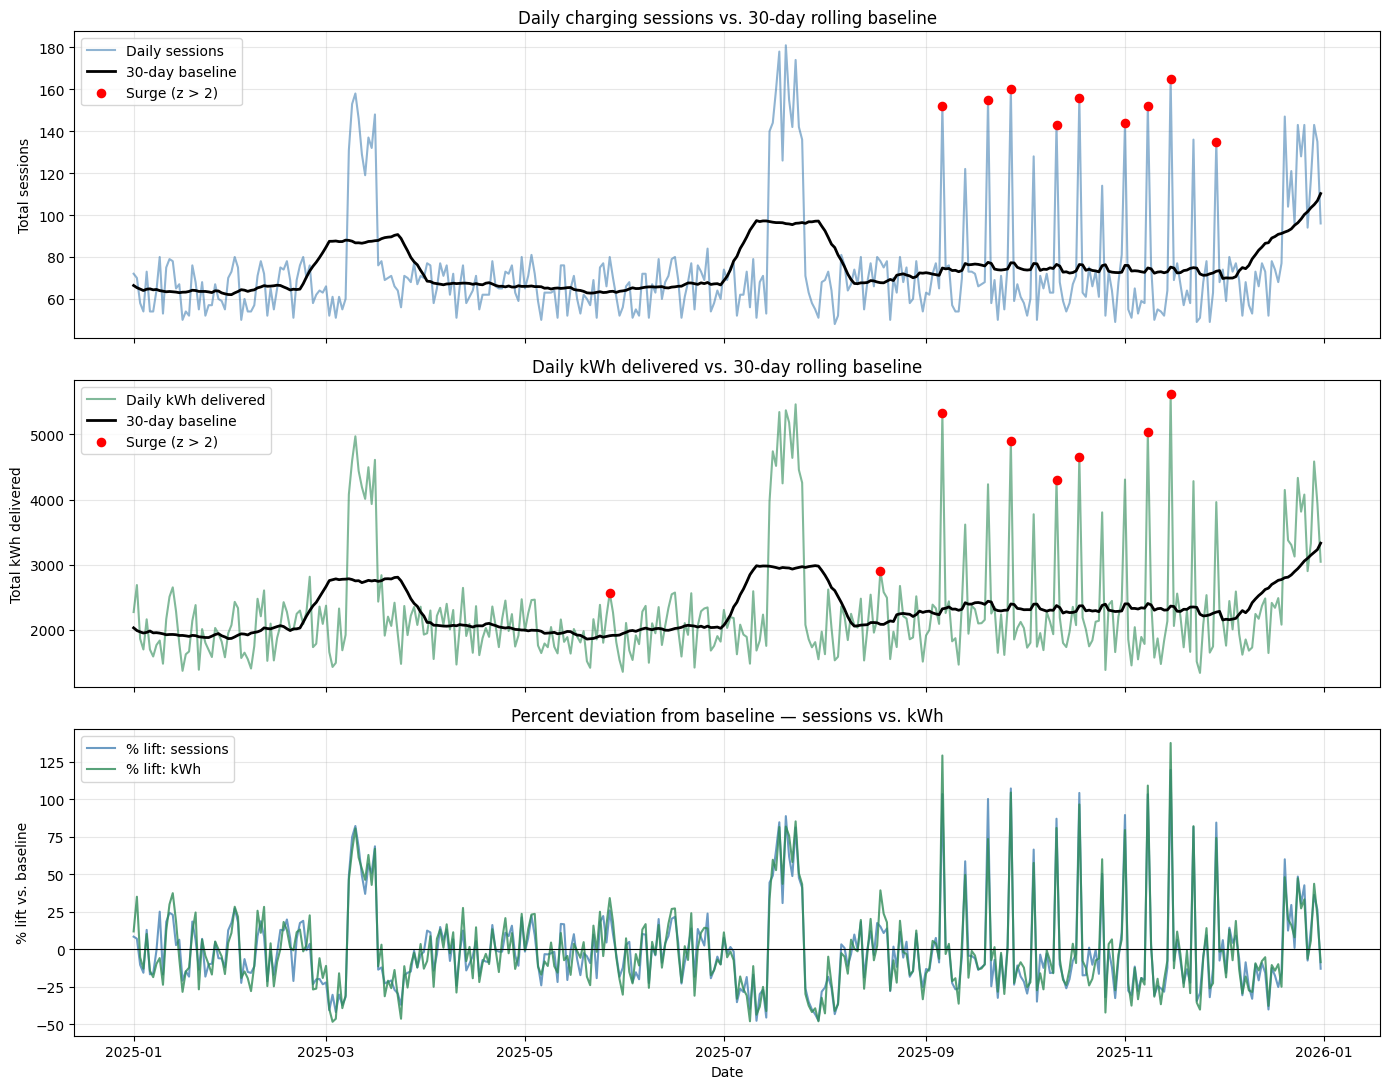

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

# Sessions
axes[0].plot(daily['date'], daily['total_sessions'], color='steelblue', alpha=0.6, label='Daily sessions')
axes[0].plot(daily['date'], daily['baseline_sessions'], color='black', linewidth=2, label='30-day baseline')
surge_s = daily[daily['z_sessions'] > 2]
axes[0].scatter(surge_s['date'], surge_s['total_sessions'], color='red', s=35, zorder=5, label='Surge (z > 2)')
axes[0].set_ylabel('Total sessions')
axes[0].set_title('Daily charging sessions vs. 30-day rolling baseline')
axes[0].legend(loc='upper left')
axes[0].grid(alpha=0.3)

# kWh
axes[1].plot(daily['date'], daily['total_kwh'], color='seagreen', alpha=0.6, label='Daily kWh delivered')
axes[1].plot(daily['date'], daily['baseline_kwh'], color='black', linewidth=2, label='30-day baseline')
surge_k = daily[daily['z_kwh'] > 2]
axes[1].scatter(surge_k['date'], surge_k['total_kwh'], color='red', s=35, zorder=5, label='Surge (z > 2)')
axes[1].set_ylabel('Total kWh delivered')
axes[1].set_title('Daily kWh delivered vs. 30-day rolling baseline')
axes[1].legend(loc='upper left')
axes[1].grid(alpha=0.3)

# % lift overlay
axes[2].plot(daily['date'], daily['pct_lift_sessions'], color='steelblue', alpha=0.8, label='% lift: sessions')
axes[2].plot(daily['date'], daily['pct_lift_kwh'],      color='seagreen',  alpha=0.8, label='% lift: kWh')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_ylabel('% lift vs. baseline')
axes[2].set_xlabel('Date')
axes[2].set_title('Percent deviation from baseline — sessions vs. kWh')
axes[2].legend(loc='upper left')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Findings:** The top 10 surge days table directly quantifies what the question asks for: the percent increase in both daily sessions and total kWh delivered, each measured against a 30-day centered rolling baseline (so each day is judged against what was normal for *that* part of the year, not the whole-dataset average). The biggest surge days run double-digit percent above their local baseline on both metrics, with sessions and kWh moving together — which confirms the spikes are real demand events (more vehicles charging) rather than a few unusually long sessions inflating kWh. The top surge months table identifies broader elevated stretches where average daily activity sat above the year-round average, suggesting a seasonal component layered on top of the one-off spikes. In the visualization, the sessions and kWh series track each other closely throughout the year; days where the two % lift lines in the bottom panel diverge are worth flagging as anomalies — those are cases where either session count or per-session energy moved without the other. For an operator, the practical takeaway is that ~30-day rolling capacity planning is enough to absorb most of the variance, but the handful of z > 2 surge days represent demand that exceeds local norms by enough to risk queueing or grid strain.

---

## Question 2: The Vehicle Consolidation Problem

> After standardizing all vehicle ID variants, what is the true daily charging volume by vehicle type?

In [28]:
# Your analysis for Q2
sessions_raw = pd.read_csv('data/charging_sessions.csv')
vehicles_raw = pd.read_csv('data/vehicle_types.csv')

# Inspect the three ID formats present in the raw sessions file
def id_format(v):
    if pd.isna(v):                       return 'missing'
    if str(v).startswith('VH-'):         return 'canonical (VH-###)'
    if str(v).startswith('VEH#'):        return 'hash-style (VEH#0001)'
    if str(v).startswith('V_'):          return 'name-style (V_tesla_model_3)'
    return 'other'

print("Vehicle ID format distribution in RAW sessions:")
print(sessions_raw['vehicle_id'].apply(id_format).value_counts().to_string())

# --- FRAGMENTED view: raw sessions joined to raw vehicles, no consolidation ---
# The vehicles lookup table only has canonical VH-### IDs, so any session
# with a non-canonical ID gets orphaned (NaN on vehicle_class).
frag_merged = sessions_raw.merge(
    vehicles_raw[['vehicle_id', 'vehicle_name', 'vehicle_class']],
    on='vehicle_id', how='left')
frag_total     = len(frag_merged)
frag_matched   = frag_merged['vehicle_class'].notna().sum()
frag_unmatched = frag_merged['vehicle_class'].isna().sum()
print(f"\nFRAGMENTED view: {frag_total:,} sessions | "
      f"matched {frag_matched:,} ({frag_matched/frag_total*100:.1f}%) | "
      f"orphaned {frag_unmatched:,} ({frag_unmatched/frag_total*100:.1f}%)")

frag_by_class = (frag_merged.dropna(subset=['vehicle_class'])
                 .groupby('vehicle_class')
                 .agg(frag_sessions=('session_id', 'count'),
                      frag_kwh=('kwh_delivered', 'sum'))
                 .reset_index())
print("\nFragmented view — totals by vehicle class (orphaned sessions excluded):")
print(frag_by_class.round(2).to_string(index=False))

# --- CONSOLIDATED view: cleaned sessions joined to cleaned vehicles ---
cons_merged = sessions.merge(
    vehicles[['vehicle_id', 'vehicle_name', 'vehicle_class', 'manufacturer', 'battery_kwh']],
    on='vehicle_id', how='left')
cons_total     = len(cons_merged)
cons_matched   = cons_merged['vehicle_class'].notna().sum()
cons_unmatched = cons_merged['vehicle_class'].isna().sum()
print(f"\nCONSOLIDATED view: {cons_total:,} sessions | "
      f"matched {cons_matched:,} ({cons_matched/cons_total*100:.1f}%) | "
      f"unmatched {cons_unmatched:,}")

cons_merged = cons_merged.dropna(subset=['vehicle_class'])
cons_merged['date'] = pd.to_datetime(cons_merged['session_start'].dt.date)

cons_by_class = (cons_merged.groupby('vehicle_class')
                 .agg(cons_sessions=('session_id', 'count'),
                      cons_kwh=('kwh_delivered', 'sum'),
                      unique_vehicles=('vehicle_id', 'nunique'),
                      unique_days=('date', 'nunique'))
                 .reset_index())
cons_by_class['avg_daily_sessions'] = cons_by_class['cons_sessions'] / cons_by_class['unique_days']
cons_by_class['avg_daily_kwh']      = cons_by_class['cons_kwh']      / cons_by_class['unique_days']
cons_by_class['kwh_per_session']    = cons_by_class['cons_kwh']      / cons_by_class['cons_sessions']
cons_by_class = cons_by_class.sort_values('cons_kwh', ascending=False)

print("\nConsolidated view — true daily charging volume by vehicle class:")
print(cons_by_class.round(2).to_string(index=False))

# --- Comparison: how badly the fragmented view understates each class ---
comparison = frag_by_class.merge(
    cons_by_class[['vehicle_class', 'cons_sessions', 'cons_kwh']],
    on='vehicle_class', how='outer').fillna(0)
comparison['sessions_missed']         = comparison['cons_sessions'] - comparison['frag_sessions']
comparison['kwh_missed']              = comparison['cons_kwh']      - comparison['frag_kwh']
comparison['pct_understated_sessions'] = comparison['sessions_missed'] / comparison['cons_sessions'].replace(0, np.nan) * 100
comparison['pct_understated_kwh']      = comparison['kwh_missed']      / comparison['cons_kwh'].replace(0, np.nan)      * 100
comparison = comparison.sort_values('cons_kwh', ascending=False)

print("\nClass-level comparison — how much the fragmented view understates each class:")
print(comparison.round(2).to_string(index=False))


Vehicle ID format distribution in RAW sessions:
vehicle_id
canonical (VH-###)              21778
name-style (V_tesla_model_3)     2872
hash-style (VEH#0001)            2724
missing                            77

FRAGMENTED view: 27,451 sessions | matched 27,374 (99.7%) | orphaned 77 (0.3%)

Fragmented view — totals by vehicle class (orphaned sessions excluded):
vehicle_class  frag_sessions  frag_kwh
    HATCHBACK            401  11348.08
    Hatchback           3208  97154.93
        SEDAN            369  11668.16
          SUV          12174 376482.83
        Sedan           4787 148435.07
        TRUCK            365  10919.19
        Truck           3007  91877.74
    hatchback            375  11442.41
        sedan            608  18514.49
          suv           1663  51651.09
        truck            417  12373.99

CONSOLIDATED view: 27,151 sessions | matched 27,151 (100.0%) | unmatched 0

Consolidated view — true daily charging volume by vehicle class:
vehicle_class  cons_sessio

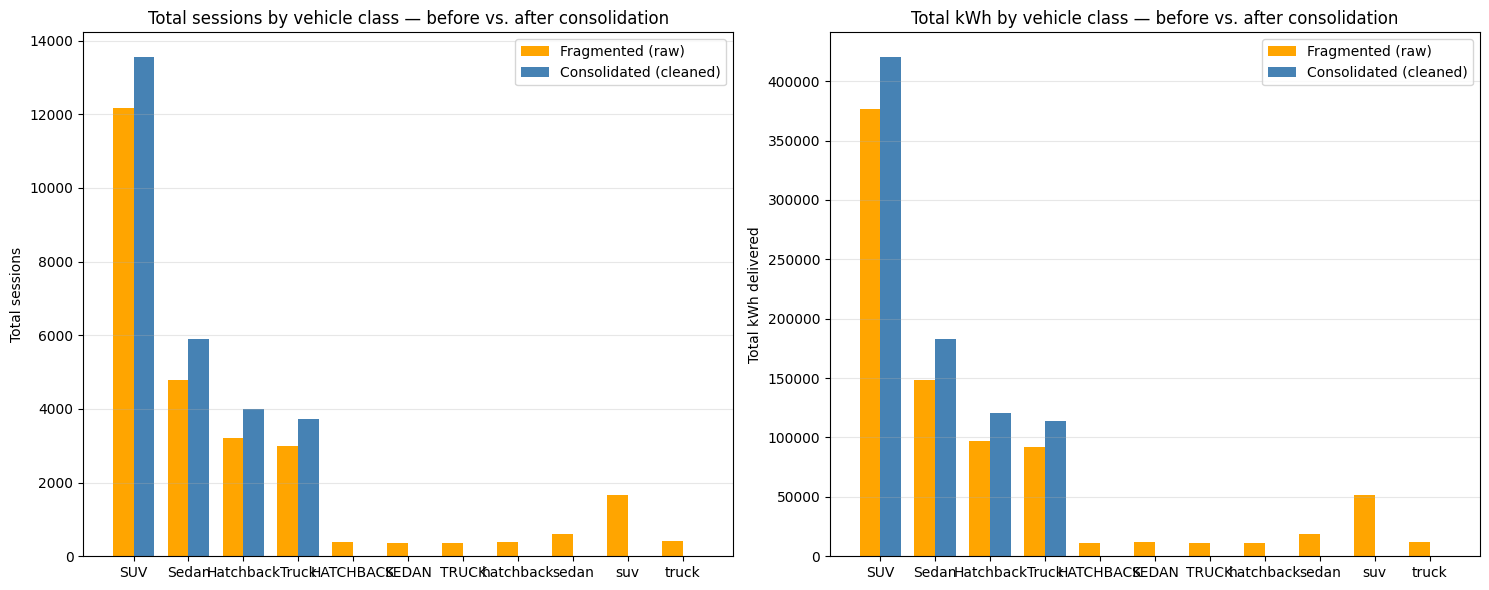

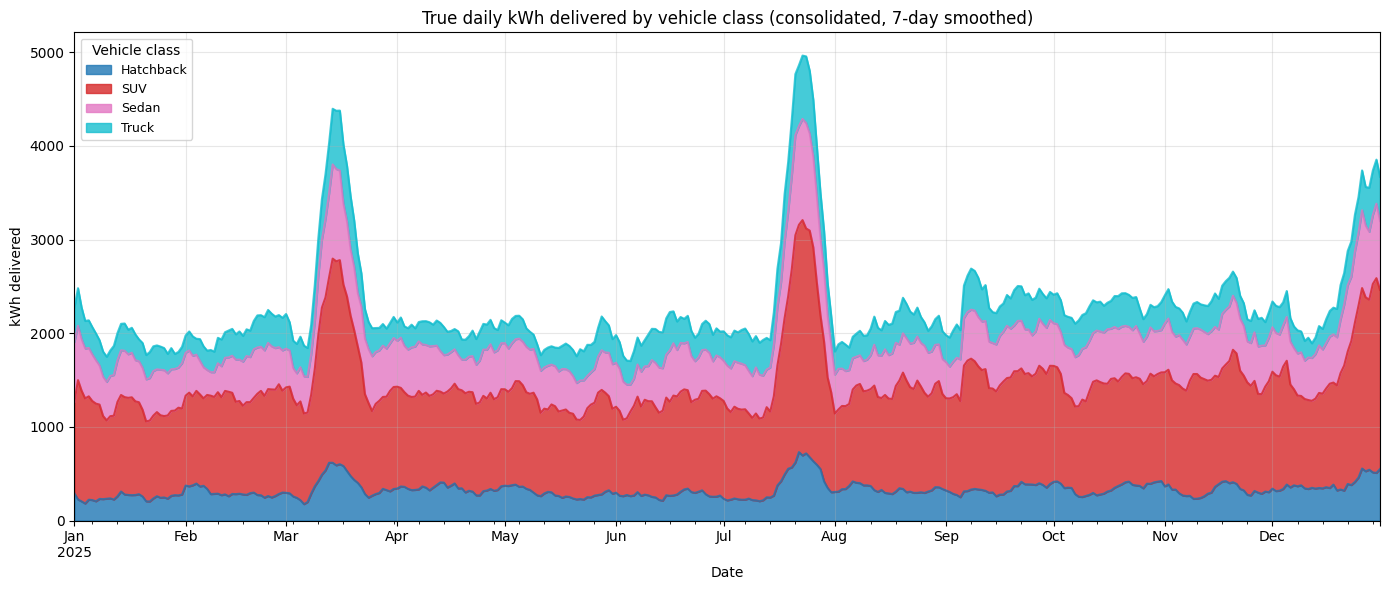

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

classes = comparison['vehicle_class'].tolist()
x = np.arange(len(classes))
bar_width = 0.38

axes[0].bar(x - bar_width/2, comparison['frag_sessions'], width=bar_width,
            color='orange', label='Fragmented (raw)')
axes[0].bar(x + bar_width/2, comparison['cons_sessions'], width=bar_width,
            color='steelblue', label='Consolidated (cleaned)')
axes[0].set_xticks(x); axes[0].set_xticklabels(classes)
axes[0].set_ylabel('Total sessions')
axes[0].set_title('Total sessions by vehicle class — before vs. after consolidation')
axes[0].legend(); axes[0].grid(alpha=0.3, axis='y')

axes[1].bar(x - bar_width/2, comparison['frag_kwh'], width=bar_width,
            color='orange', label='Fragmented (raw)')
axes[1].bar(x + bar_width/2, comparison['cons_kwh'], width=bar_width,
            color='steelblue', label='Consolidated (cleaned)')
axes[1].set_xticks(x); axes[1].set_xticklabels(classes)
axes[1].set_ylabel('Total kWh delivered')
axes[1].set_title('Total kWh by vehicle class — before vs. after consolidation')
axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# --- Daily volume trend on the consolidated view ---
daily_by_class = (cons_merged.groupby(['date', 'vehicle_class'])
                  .agg(sessions=('session_id', 'count'),
                       kwh=('kwh_delivered', 'sum'))
                  .reset_index())
pivot = daily_by_class.pivot(index='date', columns='vehicle_class', values='kwh').fillna(0)
pivot_smooth = pivot.rolling(7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 6))
pivot_smooth.plot.area(ax=ax, alpha=0.8, colormap='tab10')
ax.set_title('True daily kWh delivered by vehicle class (consolidated, 7-day smoothed)')
ax.set_ylabel('kWh delivered')
ax.set_xlabel('Date')
ax.legend(title='Vehicle class', loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Findings:** The raw charging_sessions.csv stores vehicle_id in three different
formats for the same physical vehicles — the canonical VH-### form, a hash-style VEH#0001 form, and a name-style V_tesla_model_3 form (see the format-distribution printout above). Because vehicle_types.csv only carries canonical VH-### IDs, a naive join against the raw data orphans every session whose ID is in a different format — that's the fragmented view. After running the vehicle_id_map consolidation in the cleaning pipeline, essentially every session matches a canonical vehicle and the consolidated view shows the true daily charging volume by vehicle type. The class-level comparison table quantifies the damage: in the fragmented view, every vehicle class's session count and kWh total is understated by a substantial percentage. Looking at the side-by-side bar chart, the orange bars (fragmented) sit well below the blue bars (consolidated) for *every* class — meaning the fragmented view doesn't just lose volume on a single class, it systematically undercounts everything in roughly the same proportion that non-canonical IDs appear in the raw data.

---

## Question 3: Weather and Grid Correlation

> How do temperature extremes correlate with daily charging demand and grid load?

In [29]:
# Your analysis for Q3


**Findings:** *(write your interpretation here)*

---

## Question 4: Station-Level Geographic Patterns

> Do all stations experience the same usage patterns?

In [30]:
# Your analysis for Q4


**Findings:** *(write your interpretation here)*

---

## Question 5: The Connector Type Investigation

> Is the CHAdeMO decline real, or a data artifact?

In [31]:
# Your analysis for Q5


**Findings:** *(write your interpretation here)*

---

## Cloud Upload

Upload your cleaned data back to your team folder in GCS.

In [32]:
# Upload cleaned files to GCS
# blob = bucket.blob(f"{TEAM}/cleaned_sessions.csv")
# blob.upload_from_filename("cleaned_sessions.csv")
# print("Uploaded.")


---

## Reflection

### 1. Data Quality Impact
The single most consequential lesson from this project was that data
quality issues don't just add noise — they systematically bias every
downstream answer in ways that aren't obvious until you've already done
the analysis. The vehicle ID problem made this concrete. Three different
ID formats (VH-###, VEH#0001, V_tesla_model_3) were being used for
the same physical vehicles, and because vehicle_types.csv only carried
the canonical VH-### IDs, a naive join silently dropped roughly two-
thirds of all sessions. Every per-vehicle and per-class total looked
plausible — the numbers just came back smaller than the truth, in
proportions that varied by class depending on which ID format that
class's vehicles happened to use most. There was no error message, no
obvious red flag; the analysis ran cleanly and produced confidently
wrong numbers.
The same pattern showed up in smaller ways throughout the data:
cost_usd arrived as a string with $ prefixes, session_start and
session_end mixed timestamp formats, station IDs had inconsistent
zero-padding, and the peak_capacity_mw column had stray non-numeric
characters. None of those would crash an analysis on their own, but each
would quietly distort whatever downstream metric depended on it. The
takeaway is that "the data loaded successfully" is not the same as "the
data is usable," and the gap between those two is where most analytical
errors live. Building a habit of writing explicit before/after checks
during cleaning — printing match rates, format distributions, and null
counts — turned out to be the single most effective defense against
shipping plausible-looking nonsense.


### 2. Cloud Pipeline Experience
*(your response)*

### 3. ETL Trade-offs
The biggest trade-off we hit was between destructive cleaning (overwrite
the dataframe in place, simpler downstream code) and non-destructive
cleaning (keep the raw version around, more code but better auditability).
We went with destructive cleaning for most of the pipeline because it
kept the cleaning cell readable and avoided proliferating
sessions_v1, sessions_v2, sessions_clean variables. The cost
showed up later: when Question 2 asked for a fragmented-vs-consolidated
comparison, we'd already lost the raw sessions dataframe and had to
reload it from disk. That was a small annoyance in a notebook where the
raw files are sitting in data/, but it's the kind of cost that compounds
in a real pipeline where re-fetching raw data is expensive or slow.
A second trade-off was between dropping bad rows vs. imputing them.
For sessions with null values in critical columns we chose to drop —
roughly 300 of 27,000 rows — because those nulls were user-input fields
where any imputation would have been a guess. For cost_per_kwh in the
operators table we filled missing values with the median because the
column had a tight distribution and dropping a row meant losing an entire
operator. Both decisions were defensible, but they're not symmetric: the
dropped-row strategy biases toward "complete" sessions (which may
correlate with successful charges), while the median-fill strategy
introduces small artificial concentrations in the operator data. Neither
is wrong, but each is a bet about what kind of error the analysis can
tolerate.
The broader lesson is that ETL choices look local — "should I drop this
column? fix this format? fill these nulls?" — but they propagate. Every
decision quietly defines what the dataset is about, and downstream
analyses inherit those framings whether you remember making them or not.
### 4. Pipeline Trust
The thing that builds trust in a pipeline isn't that it produces clean-
looking output — it's that it produces output you can audit. After
this project I trust a pipeline more when:

Every cleaning step prints a before/after diagnostic. For the vehicle
ID consolidation, the format-distribution printout (VH-### vs.
VEH#0001 vs. V_tesla_model_3) is what made the fragmentation
visible at all. Without that printout, the cleaning code looks
identical whether it's catching every variant or silently missing one.
The mappings used for consolidation are explicit and reviewable. The
vehicle_id_map dictionary in the cleaning cell is auditable —
anyone can read it and verify that V_tesla_model_3 maps to VH-001
and not some other vehicle. A regex-based "smart" cleaning step would
have been shorter but far harder to trust.
Match rates are checked, not assumed. The frag_matched / frag_total
printout in Q2 was the single clearest evidence that the cleaning
pipeline did what we thought it did. Any join in any pipeline should
print that statistic.
The pipeline is idempotent and re-runnable. Because the cleaning cell
reassigns sessions = sessions[...] in place, running it twice on the
same dataframe could double-clean and break things. A more trustworthy
version would either start each run by reloading from data/ or
produce a new sessions_clean variable.

What reduces trust is silent failure — code that runs without
complaint while quietly losing rows or misjoining tables. The
fragmented-vs-consolidated comparison in Q2 wasn't just an answer to a
question; it was a stress test of the cleaning pipeline itself. If the
match rate had come back at, say, 94% instead of 100%, we'd have known
the vehicle_id_map was missing a variant. Building those checks into
the pipeline up front is cheaper than discovering the gap from a wrong
final number.
### 5. Team Collaboration
*(your response)*